In [23]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [24]:
n = 1000
d = 50

X = np.random.randn(n, d)
true_w = np.random.randn(d)
y = X @ true_w + 0.1 * np.random.randn(n)

lam = 1e-2

In [25]:
def f_i(w, i):
    return 0.5 * (X[i] @ w - y[i])**2 + (lam/2) * np.linalg.norm(w)**2

def grad_f_i(w, i):
    return (X[i] @ w - y[i]) * X[i] + lam * w

def loss(w):
    return np.mean([f_i(w, i) for i in range(n)])

In [26]:
def SAG(w_init, lr, epochs):
    w = w_init.copy()
    memory = np.zeros((n, d))
    grad_avg = np.zeros(d)
    history = []
    for epoch in range(epochs):
        for _ in range(n):
            i = np.random.randint(0, n)
            grad_new = grad_f_i(w, i)
            grad_avg += (grad_new - memory[i]) / n
            memory[i] = grad_new
            w -= lr * grad_avg
        history.append(loss(w))
    return w, history

In [27]:
def SAGA(w_init, lr, epochs):
    w = w_init.copy()
    memory = np.zeros((n, d))
    grad_avg = np.zeros(d)
    history = []
    for epoch in range(epochs):
        for _ in range(n):
            i = np.random.randint(0, n)
            grad_new = grad_f_i(w, i)
            gk = grad_new - memory[i] + grad_avg
            grad_avg += (grad_new - memory[i]) / n
            memory[i] = grad_new
            w -= lr * gk
        history.append(loss(w))
    return w, history

In [28]:
w0 = np.zeros(d)

lr = 0.01
epochs = 100

w_sag, hist_sag = SAG(w0, lr, epochs)
w_saga, hist_saga = SAGA(w0, lr, epochs)

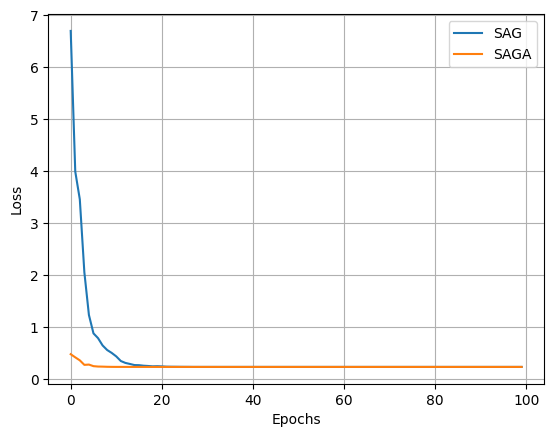

In [29]:
plt.plot(hist_sag, label="SAG")
plt.plot(hist_saga, label="SAGA")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [30]:
print(np.linalg.norm(w_sag - true_w))
print(np.linalg.norm(w_saga - true_w))

0.07843443583942612
0.07843443523381283
